<a href="https://colab.research.google.com/github/SmileCat42/Deep-Learning/blob/main/FshionFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.datasets import cifar10

# 1. โหลดข้อมูล
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [2]:
print(f"ขนาดรูปเทรน: {train_images.shape}")

ขนาดรูปเทรน: (50000, 32, 32, 3)


In [3]:
from keras import models
from keras import layers
from tensorflow.keras.applications import VGG16

conv_base = VGG16(
weights='imagenet',
include_top=False,
input_shape=(150, 150, 3)
)

model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

อย่าลืมปรับขนาดรูปให้เท่ากับขนาดที่ VGG16 รับได้ คือ 64*64

In [4]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import VGG16

# 1. ดึง VGG16 มาแบบไม่เอาส่วนหัว (include_top=False)
conv_base = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(64, 64, 3)) # เราจะขยายรูปเป็น 64x64

# 2. Freeze ฐานไว้ก่อน (Strategy 2 ที่เราคุยกัน)
conv_base.trainable = False

# 3. ประกอบร่างโมเดล
model = models.Sequential([
    # ขยายขนาดจาก 32x32 เป็น 64x64
    layers.UpSampling2D(size=(2, 2), input_shape=(32, 32, 3)),

    conv_base, # ฐาน VGG16

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # ป้องกัน Overfitting
    layers.Dense(10, activation='softmax') # ออก 10 คลาส
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/up_sampling2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,241,802 (58.14 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [5]:
model.compile(optimizer=optimizers.RMSprop(learning_rate=2e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [6]:
history = model.fit(train_images, train_labels,
                    epochs=10,
                    batch_size=64,
                    validation_data=(test_images, test_labels))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step - accuracy: 0.2802 - loss: 15.6983 - val_accuracy: 0.5109 - val_loss: 4.5549
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.4216 - loss: 5.9524 - val_accuracy: 0.5433 - val_loss: 2.5545
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.4395 - loss: 3.2577 - val_accuracy: 0.5400 - val_loss: 1.8046
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.4502 - loss: 2.2947 - val_accuracy: 0.5460 - val_loss: 1.5663
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.4747 - loss: 1.9555 - val_accuracy: 0.5684 - val_loss: 1.4557
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.5002 - loss: 1.7861 - val_accuracy: 0.5854 - val_loss: 1.3924
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - accuracy: 0.5226 - loss: 1.6708 - val_accuracy: 0.5987 - val_loss: 1.3456
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.5459 - loss: 1.5999 -

acc ต่ำมาก แต่เป็นผลลัพธ์ที่ดี เพราะชุดข้อมูลยากหลาย คลาส การเรียน 10 อีพอกอาจยังอาจเกินไปสำหรับโมเดล

In [7]:
# 1. ปลดล็อคให้ VGG16 เทรนได้
conv_base.trainable = True

# 2. แต่เราจะล็อคชั้นแรกๆ ไว้ ปลดแค่ชั้นท้ายๆ (เช่น block5)
for layer in conv_base.layers:
    if 'block5' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

# 3. Compile ใหม่ด้วย Learning Rate ที่ "ต่ำมากๆ" (ป้องกันโมเดลเอ๋อ)
model.compile(optimizer=optimizers.RMSprop(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. เทรนต่ออีกสัก 10-20 Epochs

In [8]:
history = model.fit(train_images, train_labels,
                    epochs=10,
                    batch_size=64,
                    validation_data=(test_images, test_labels))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 60ms/step - accuracy: 0.6105 - loss: 1.2521 - val_accuracy: 0.7011 - val_loss: 0.9537
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 77s 57ms/step - accuracy: 0.6895 - loss: 0.9742 - val_accuracy: 0.7421 - val_loss: 0.8405
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.7327 - loss: 0.8100 - val_accuracy: 0.7655 - val_loss: 0.7959
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 61ms/step - accuracy: 0.7712 - loss: 0.6784 - val_accuracy: 0.7817 - val_loss: 0.7512
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.7989 - loss: 0.5882 - val_accuracy: 0.7940 - val_loss: 0.7257
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.8228 - loss: 0.5173 - val_accuracy: 0.8035 - val_loss: 0.7077
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.8400 - loss: 0.4507 - val_accuracy: 0.8082 - val_loss: 0.7133
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.8568 - loss: 0.4028 - 

ทดสอบโดยการสุ่มจากชุดข้อมูล keras

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


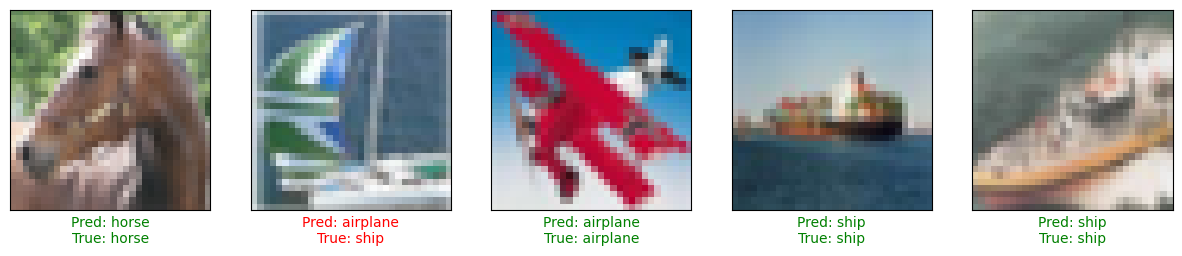

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# 1. กำหนดชื่อคลาสของ CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 2. สุ่มเลือกรูปจากชุด Test มา 5 รูป
indices = np.random.randint(0, len(test_images), 5)
sample_images = test_images[indices]
sample_labels = test_labels[indices]

# 3. ให้โมเดลทำนาย
predictions = model.predict(sample_images)

# 4. แสดงผลลัพธ์
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(sample_images[i])

    predicted_label = np.argmax(predictions[i])
    true_label = sample_labels[i][0]

    # ถ้าทายถูกตัวหนังสือสีเขียว ถ้าผิดสีแดง
    color = 'green' if predicted_label == true_label else 'red'

    plt.xlabel(f"Pred: {class_names[predicted_label]}\nTrue: {class_names[true_label]}", color=color)
plt.show()

ทดสอบโดยการอัพโหลดรูปของเราเอง

Saving 22.png to 22 (1).png


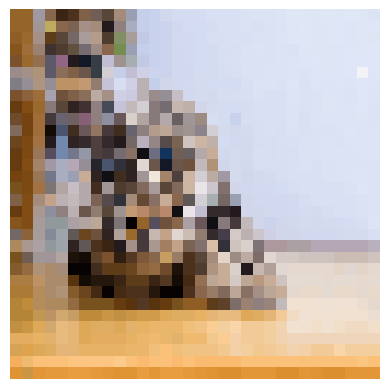

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
-----------------------------------
📷 ไฟล์: 22 (1).png
🎯 โมเดลทายว่าเป็น: 'CAT'
✅ ความมั่นใจ: 87.92%
-----------------------------------


In [14]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. กำหนดรายชื่อคลาส CIFAR-10 ให้ตรงกับโมเดล
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 2. ฟังก์ชันสำหรับอัปโหลดรูป (My Computer)
uploaded = files.upload()

for fn in uploaded.keys():
    # 3. เตรียมรูปภาพ (ต้อง Resize เป็น 32x32 เท่าตอนเทรน)
    path = '/content/' + fn
    img = image.load_img(path, target_size=(32, 32)) # สำคัญมาก! ต้อง 32x32

    # 4. แสดงรูปภาพที่เราอัปโหลด
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # 5. แปลงรูปภาพเป็นตัวเลข (Array) และ Normalize
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0) # เพิ่มมิติให้เป็น (1, 32, 32, 3)
    x /= 255.0                   # อย่าลืมหาร 255 เหมือนตอนเทรน

    # 6. ให้โมเดลทำนาย
    # โมเดลจะส่งค่าความมั่นใจ (Probability) ของทั้ง 10 คลาสออกมา
    predictions = model.predict(x)

    # 7. หาคลาสที่มีค่าความมั่นใจสูงที่สุด
    score = predictions[0]
    predicted_class_index = np.argmax(score)
    predicted_label = class_names[predicted_class_index]
    confidence = np.max(score) * 100

    # 8. สรุปผลลัพธ์
    print(f"-----------------------------------")
    print(f"📷 ไฟล์: {fn}")
    print(f"🎯 โมเดลทายว่าเป็น: '{predicted_label.upper()}'")
    print(f"✅ ความมั่นใจ: {confidence:.2f}%")
    print(f"-----------------------------------")

    # (Optional) ดูความมั่นใจของคลาสอื่นๆ
    # for i in range(10):
    #     print(f"- {class_names[i]}: {score[i]*100:.2f}%")

ทายถูกแต่ใน cifar10 รูปที่เราอัพยังไม่เคยถูกเลย ต้องใส่ Aug ให้มันเ่กงขึ้น

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. สร้าง "เครื่องผลิตรูปภาพจำลอง" (Data Augmentation Generator)
# เราจะตั้งค่าให้มันแอบแก้รูปตอนเทรนแบบสุ่ม (Random)
train_datagen = ImageDataGenerator(
    rescale=1./255,            # Normalize (ทำเหมือนเดิม)
    rotation_range=20,         # สุ่มหมุนรูปได้ไม่เกิน 20 องศา
    width_shift_range=0.1,     # สุ่มเลื่อนรูปซ้าย-ขวา 10%
    height_shift_range=0.1,    # สุ่มเลื่อนรูปบน-ล่าง 10%
    shear_range=0.1,           # สุ่มดึงภาพให้เบี้ยว (เหมือนมองเอียงๆ)
    zoom_range=0.1,            # สุ่มซูมเข้า-ออก 10%
    horizontal_flip=True,      # สุ่มกลับด้านซ้าย-ขวา (เช่น เครื่องบินบินกลับทาง)
    fill_mode='nearest'        # ถ้าเลื่อนรูปแล้วมีที่ว่าง ให้ดึงสีข้างๆ มาเติม
)

# 2. สำหรับข้อมูล Validation/Test เรา "ไม่ทำ" Augmentation นะครับ (แค่ Normalize พอ)
test_datagen = ImageDataGenerator(rescale=1./255)

# 3. เตรียม Data Stream จาก NumPy Array (x_train, y_train คือข้อมูล CIFAR-10 เดิม)
train_generator = train_datagen.flow(
    train_images, train_labels,
    batch_size=64
)

validation_generator = test_datagen.flow(
    test_images, test_labels,
    batch_size=64
)

In [12]:
import tensorflow as tf
from tensorflow.keras import optimizers

# แนะนำให้ใช้ EarlyStopping ด้วยนะครับ เพราะ Data Augmentation จะทำให้เทรนนานขึ้น
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# เทรนต่อสัก 30 Epochs (หรือจนกว่ามันจะหยุดเอง)
history_aug = model.fit(
    train_generator,                     # ใช้ Generator แทน Array
    epochs=20,                           # ตั้งไว้เยอะหน่อย
    validation_data=validation_generator, # ใช้ Generator สำหรับ Valid
    callbacks=[callback]                 # ใส่ตัวหยุดเมื่อเก่งที่สุด
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 67ms/step - accuracy: 0.5947 - loss: 1.1743 - val_accuracy: 0.7529 - val_loss: 0.7155
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.6986 - loss: 0.8795 - val_accuracy: 0.7677 - val_loss: 0.6675
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.7232 - loss: 0.8124 - val_accuracy: 0.7748 - val_loss: 0.6519
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.7428 - loss: 0.7566 - val_accuracy: 0.7912 - val_loss: 0.6017
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.7567 - loss: 0.7096 - val_accuracy: 0.7988 - val_loss: 0.5872
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.7651 - loss: 0.6850 - val_accuracy: 0.7963 - val_loss: 0.5952
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.7757 - loss: 0.6555 - val_accuracy: 0.8077 - val_loss: 0.5593
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.7824 - loss: 0.6317 - 

Saving 52.png to 52.png


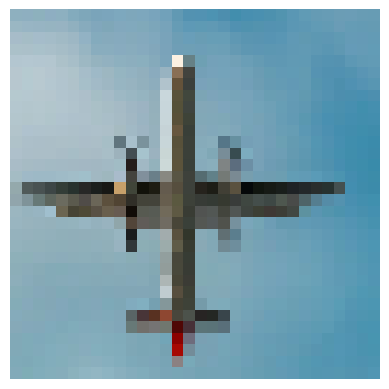

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
-----------------------------------
📷 ไฟล์: 52.png
🎯 โมเดลทายว่าเป็น: 'AIRPLANE'
✅ ความมั่นใจ: 99.98%
-----------------------------------


In [13]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. กำหนดรายชื่อคลาส CIFAR-10 ให้ตรงกับโมเดล
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 2. ฟังก์ชันสำหรับอัปโหลดรูป (My Computer)
uploaded = files.upload()

for fn in uploaded.keys():
    # 3. เตรียมรูปภาพ (ต้อง Resize เป็น 32x32 เท่าตอนเทรน)
    path = '/content/' + fn
    img = image.load_img(path, target_size=(32, 32)) # สำคัญมาก! ต้อง 32x32

    # 4. แสดงรูปภาพที่เราอัปโหลด
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # 5. แปลงรูปภาพเป็นตัวเลข (Array) และ Normalize
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0) # เพิ่มมิติให้เป็น (1, 32, 32, 3)
    x /= 255.0                   # อย่าลืมหาร 255 เหมือนตอนเทรน

    # 6. ให้โมเดลทำนาย
    # โมเดลจะส่งค่าความมั่นใจ (Probability) ของทั้ง 10 คลาสออกมา
    predictions = model.predict(x)

    # 7. หาคลาสที่มีค่าความมั่นใจสูงที่สุด
    score = predictions[0]
    predicted_class_index = np.argmax(score)
    predicted_label = class_names[predicted_class_index]
    confidence = np.max(score) * 100

    # 8. สรุปผลลัพธ์
    print(f"-----------------------------------")
    print(f"📷 ไฟล์: {fn}")
    print(f"🎯 โมเดลทายว่าเป็น: '{predicted_label.upper()}'")
    print(f"✅ ความมั่นใจ: {confidence:.2f}%")
    print(f"-----------------------------------")

    # (Optional) ดูความมั่นใจของคลาสอื่นๆ
    # for i in range(10):
    #     print(f"- {class_names[i]}: {score[i]*100:.2f}%")